## Variables in python 



## How Variables Work in Python

In Python, variables are used to store data values. Unlike other programming languages, Python has no command for declaring a variable — a variable is created the moment you first assign a value to it. Python is dynamically typed, meaning you don't need to specify the data type explicitly; it is inferred at runtime.

### Variable Assignment

```python
x = 10          # Integer
name = "Alice"  # String
pi = 3.14       # Float
```

### Rules for Variable Names
- Must start with a letter or underscore (`_`)
- Cannot start with a number
- Can only contain alphanumeric characters and underscores
- Case-sensitive (`age`, `Age`, and `AGE` are different variables)

### Common Variable Types and Their Sizes

| Data Type | Example | Typical Size (bytes) | Description |
|-----------|---------|---------------------|-------------|
| `int` | `x = 10` | 28+ (dynamic) | Integer values; size grows with magnitude |
| `float` | `x = 3.14` | 24 | 64-bit floating point numbers |
| `bool` | `x = True` | 28 | Boolean values (`True` or `False`) |
| `str` | `x = "hello"` | 49+ (dynamic) | Text/string; size grows with length |
| `complex` | `x = 2 + 3j` | 32 | Complex numbers with real and imaginary parts |
| `list` | `x = [1, 2, 3]` | 56+ (dynamic) | Ordered, mutable collection |
| `tuple` | `x = (1, 2, 3)` | 40+ (dynamic) | Ordered, immutable collection |
| `dict` | `x = {"a": 1}` | 64+ (dynamic) | Key-value pairs |
| `set` | `x = {1, 2, 3}` | 200+ (dynamic) | Unordered collection of unique elements |
| `NoneType` | `x = None` | 16 | Represents the absence of a value |

> **Note:** Python objects carry overhead for memory management, so sizes are larger than in statically typed languages like C. The actual size of a variable can be checked using `sys.getsizeof()`.

Variable     Type         Value              Size (bytes)
int          int          10                 28
float        float        3.14               24
bool         bool         True               28
str          str          hello              46
complex      complex      (2+3j)             32
list         list         [1, 2, 3]          88
tuple        tuple        (1, 2, 3)          64
dict         dict         {'a': 1}           184
set          set          {1, 2, 3}          216
NoneType     NoneType     None               16

--- Dynamic Typing Demo ---
dynamic_var = 42              | type: int        | id: 9803912 | size: 28 bytes
dynamic_var = Now I'm a string! | type: str        | id: 132994753311024 | size: 58 bytes
dynamic_var = [1, 2, 3, 4]    | type: list       | id: 132994763397696 | size: 88 bytes

--- Memory: Heap vs Stack ---
a = [1, 2, 3], id(a) = 132994753310208
b = [1, 2, 3], id(b) = 132994753310208
a is b? True  → Both point to the SAME object on the HEAP
After 

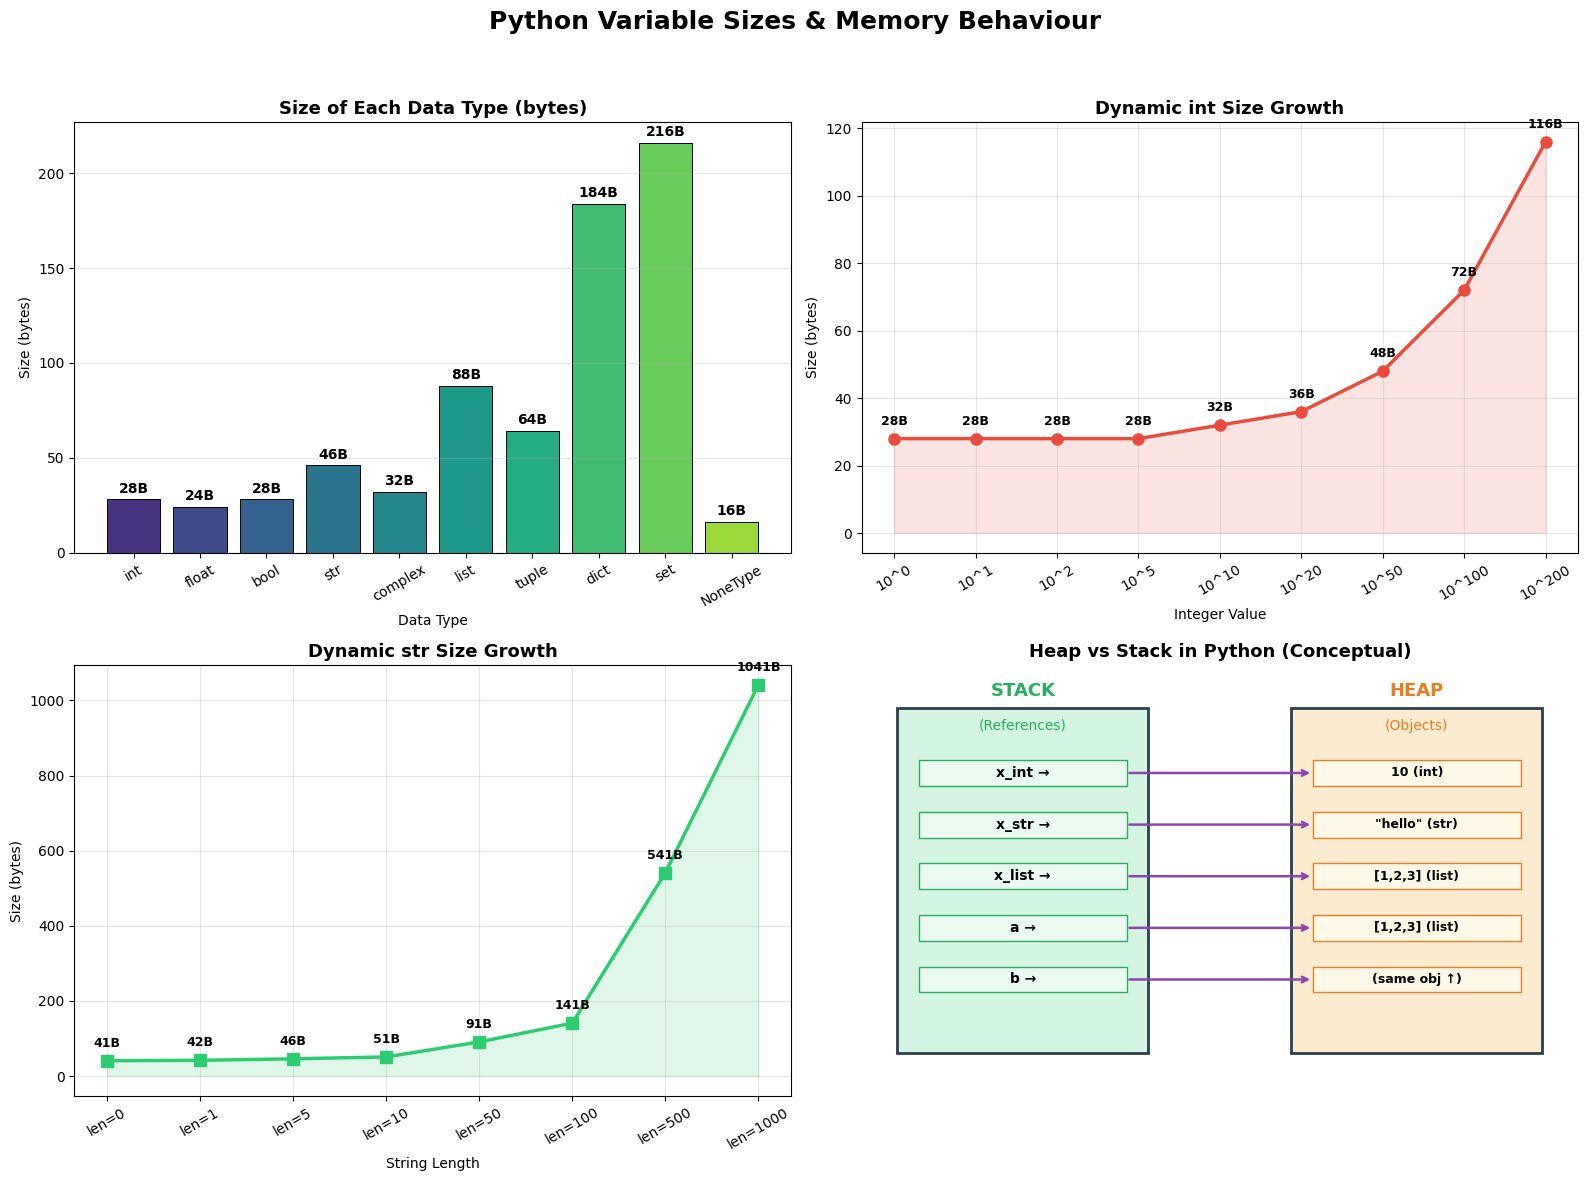

In [4]:
import sys
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1. Create variables of different types
# ============================================================
x_int = 10
x_float = 3.14
x_bool = True
x_str = "hello"
x_complex = 2 + 3j
x_list = [1, 2, 3]
x_tuple = (1, 2, 3)
x_dict = {"a": 1}
x_set = {1, 2, 3}
x_none = None

variables = {
    "int": x_int,
    "float": x_float,
    "bool": x_bool,
    "str": x_str,
    "complex": x_complex,
    "list": x_list,
    "tuple": x_tuple,
    "dict": x_dict,
    "set": x_set,
    "NoneType": x_none,
}

# ============================================================
# 2. Check sizes of each variable
# ============================================================
print("=" * 55)
print(f"{'Variable':<12} {'Type':<12} {'Value':<18} {'Size (bytes)'}")
print("=" * 55)
sizes = {}
for name, var in variables.items():
    size = sys.getsizeof(var)
    sizes[name] = size
    print(f"{name:<12} {type(var).__name__:<12} {str(var):<18} {size}")
print("=" * 55)

# ============================================================
# 3. Demonstrate DYNAMIC typing behaviour
# ============================================================
print("\n--- Dynamic Typing Demo ---")
dynamic_var = 42
print(f"dynamic_var = {dynamic_var:<15} | type: {type(dynamic_var).__name__:<10} | id: {id(dynamic_var)} | size: {sys.getsizeof(dynamic_var)} bytes")
dynamic_var = "Now I'm a string!"
print(f"dynamic_var = {dynamic_var:<15} | type: {type(dynamic_var).__name__:<10} | id: {id(dynamic_var)} | size: {sys.getsizeof(dynamic_var)} bytes")
dynamic_var = [1, 2, 3, 4]
print(f"dynamic_var = {str(dynamic_var):<15} | type: {type(dynamic_var).__name__:<10} | id: {id(dynamic_var)} | size: {sys.getsizeof(dynamic_var)} bytes")

# ============================================================
# 4. Show that ALL Python objects live on the HEAP
#    Variables on the stack are just references (pointers)
# ============================================================
print("\n--- Memory: Heap vs Stack ---")
a = [1, 2, 3]
b = a  # b is a new reference (pointer on stack) to same heap object
print(f"a = {a}, id(a) = {id(a)}")
print(f"b = {b}, id(b) = {id(b)}")
print(f"a is b? {a is b}  → Both point to the SAME object on the HEAP")
b.append(4)
print(f"After b.append(4): a = {a}, b = {b}  → Proves shared heap object")

print("""
╔══════════════════════════════════════════════════════╗
║  STACK (references/pointers)  →  HEAP (objects)     ║
║  ─────────────────────────────   ────────────────    ║
║  a  ──────────────────────────►  [1, 2, 3, 4]       ║
║  b  ──────────────────────────►  (same object)       ║
║                                                      ║
║  • All Python objects are allocated on the HEAP.     ║
║  • Variable names are references stored on STACK.    ║
║  • Garbage collector frees heap memory when          ║
║    reference count drops to zero.                    ║
╚══════════════════════════════════════════════════════╝
""")

# ============================================================
# 5. Show how int/str sizes grow dynamically
# ============================================================
int_sizes = []
int_labels = []
for exp in [0, 1, 2, 5, 10, 20, 50, 100, 200]:
    val = 10 ** exp
    int_sizes.append(sys.getsizeof(val))
    int_labels.append(f"10^{exp}")

str_sizes = []
str_labels = []
for length in [0, 1, 5, 10, 50, 100, 500, 1000]:
    val = "a" * length
    str_sizes.append(sys.getsizeof(val))
    str_labels.append(f"len={length}")

# ============================================================
# 6. Beautiful Comparison Graphs
# ============================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle("Python Variable Sizes & Memory Behaviour", fontsize=18, fontweight="bold", y=0.98)

# --- Plot 1: Bar chart – sizes of different types ---
ax1 = axes[0, 0]
types = list(sizes.keys())
vals = list(sizes.values())
colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(types)))
bars = ax1.bar(types, vals, color=colors, edgecolor="black", linewidth=0.7)
for bar, v in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 2,
             f"{v}B", ha="center", va="bottom", fontsize=10, fontweight="bold")
ax1.set_title("Size of Each Data Type (bytes)", fontsize=13, fontweight="bold")
ax1.set_ylabel("Size (bytes)")
ax1.set_xlabel("Data Type")
ax1.tick_params(axis="x", rotation=30)
ax1.grid(axis="y", alpha=0.3)

# --- Plot 2: Line chart – int size growth ---
ax2 = axes[0, 1]
ax2.plot(int_labels, int_sizes, marker="o", color="#e74c3c", linewidth=2.5, markersize=8)
ax2.fill_between(range(len(int_labels)), int_sizes, alpha=0.15, color="#e74c3c")
for i, (lbl, s) in enumerate(zip(int_labels, int_sizes)):
    ax2.annotate(f"{s}B", (i, s), textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=9, fontweight="bold")
ax2.set_title("Dynamic int Size Growth", fontsize=13, fontweight="bold")
ax2.set_ylabel("Size (bytes)")
ax2.set_xlabel("Integer Value")
ax2.tick_params(axis="x", rotation=30)
ax2.grid(alpha=0.3)

# --- Plot 3: Line chart – str size growth ---
ax3 = axes[1, 0]
ax3.plot(str_labels, str_sizes, marker="s", color="#2ecc71", linewidth=2.5, markersize=8)
ax3.fill_between(range(len(str_labels)), str_sizes, alpha=0.15, color="#2ecc71")
for i, (lbl, s) in enumerate(zip(str_labels, str_sizes)):
    ax3.annotate(f"{s}B", (i, s), textcoords="offset points", xytext=(0, 10),
                 ha="center", fontsize=9, fontweight="bold")
ax3.set_title("Dynamic str Size Growth", fontsize=13, fontweight="bold")
ax3.set_ylabel("Size (bytes)")
ax3.set_xlabel("String Length")
ax3.tick_params(axis="x", rotation=30)
ax3.grid(alpha=0.3)

# --- Plot 4: Heap vs Stack conceptual diagram ---
ax4 = axes[1, 1]
ax4.set_xlim(0, 10)
ax4.set_ylim(0, 10)
ax4.set_axis_off()
ax4.set_title("Heap vs Stack in Python (Conceptual)", fontsize=13, fontweight="bold")

# Stack box
stack_rect = plt.Rectangle((0.5, 1), 3.5, 8, linewidth=2, edgecolor="#2c3e50",
                            facecolor="#d5f5e3", linestyle="-")
ax4.add_patch(stack_rect)
ax4.text(2.25, 9.3, "STACK", ha="center", fontsize=13, fontweight="bold", color="#27ae60")
ax4.text(2.25, 8.5, "(References)", ha="center", fontsize=10, color="#27ae60")

stack_items = ["x_int →", "x_str →", "x_list →", "a →", "b →"]
for i, item in enumerate(stack_items):
    y = 7.5 - i * 1.2
    r = plt.Rectangle((0.8, y - 0.3), 2.9, 0.6, linewidth=1,
                       edgecolor="#27ae60", facecolor="#eafaf1")
    ax4.add_patch(r)
    ax4.text(2.25, y, item, ha="center", va="center", fontsize=10, fontweight="bold")

# Heap box
heap_rect = plt.Rectangle((6, 1), 3.5, 8, linewidth=2, edgecolor="#2c3e50",
                           facecolor="#fdebd0", linestyle="-")
ax4.add_patch(heap_rect)
ax4.text(7.75, 9.3, "HEAP", ha="center", fontsize=13, fontweight="bold", color="#e67e22")
ax4.text(7.75, 8.5, "(Objects)", ha="center", fontsize=10, color="#e67e22")

heap_items = ["10 (int)", '"hello" (str)', "[1,2,3] (list)", "[1,2,3] (list)", "(same obj ↑)"]
for i, item in enumerate(heap_items):
    y = 7.5 - i * 1.2
    r = plt.Rectangle((6.3, y - 0.3), 2.9, 0.6, linewidth=1,
                       edgecolor="#e67e22", facecolor="#fef9e7")
    ax4.add_patch(r)
    ax4.text(7.75, y, item, ha="center", va="center", fontsize=9, fontweight="bold")

# Arrows from stack to heap
for i in range(5):
    y = 7.5 - i * 1.2
    ax4.annotate("", xy=(6.3, y), xytext=(3.7, y),
                 arrowprops=dict(arrowstyle="->", color="#8e44ad", lw=1.8))

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

In [5]:
## Comments in python -- single line comment

In [8]:
'''Multiline 
Comments - No concept of multiline comments in python
'''

'Multiline \nComments - No concept of multiline comments in python\n'

# Miscleneous Questions

In [10]:
name1 = 'Govind'
name2 = 'Govind'
name3 = name2

print(name1==name2)
print(name1==name3)

True
True


# Typecasting in Python


In [14]:
variable1 = 123
print(variable1)
print(type(variable1))
variable1 = float(variable1)
print(variable1)
print(type(variable1))

123
<class 'int'>
123.0
<class 'float'>


## User inputs in python

In [16]:
# ============================================================
# User Input in Python — the input() function
# ============================================================

# The input() function reads a line of text from the user.
# It ALWAYS returns a **string**, regardless of what the user types.

# --- Example 1: Basic string input ---
user_name = input("Enter your name: ")
print(f"Hello, {user_name}! (type: {type(user_name).__name__})")

# --- Example 2: input() always returns a string ---
age_str = input("Enter your age: ")
print(f"Raw input: '{age_str}' → type: {type(age_str).__name__}")

# To use it as a number, you must TYPECAST explicitly
age = int(age_str)
print(f"After int(): {age} → type: {type(age).__name__}")
print(f"Next year you'll be {age + 1}!")

# --- Example 3: Float input ---
height_str = input("Enter your height in meters (e.g. 1.75): ")
height = float(height_str)
print(f"Height: {height} m → type: {type(height).__name__}")

# --- Example 4: Multiple inputs on one line (split) ---
print("\n--- Multiple Inputs Using split() ---")
data = input("Enter 3 numbers separated by spaces: ")
nums = data.split()          # returns a list of strings
print(f"Raw split: {nums} → types: {[type(n).__name__ for n in nums]}")

nums_int = [int(n) for n in nums]  # convert each to int
print(f"As integers: {nums_int} → Sum = {sum(nums_int)}")

# --- Example 5: Inline typecasting (common shorthand) ---
print("\n--- Inline Typecasting ---")
radius = float(input("Enter radius of a circle: "))
area = 3.14159 * radius ** 2
print(f"Radius: {radius}, Area: {area:.2f}")

# --- Summary ---
print("""
╔════════════════════════════════════════════════════════════╗
║                  input() — Key Points                     ║
╠════════════════════════════════════════════════════════════╣
║  1. input(prompt) displays prompt & waits for user input  ║
║  2. ALWAYS returns a string (str)                         ║
║  3. Use int(), float(), bool() etc. to typecast           ║
║  4. Use .split() to read multiple values in one line      ║
║  5. Common pattern: int(input("Enter a number: "))        ║
╚════════════════════════════════════════════════════════════╝
""")

Hello, Govind! (type: str)
Raw input: '23' → type: str
After int(): 23 → type: int
Next year you'll be 24!
Height: 1.75 m → type: float

--- Multiple Inputs Using split() ---
Raw split: ['12', '34', '56'] → types: ['str', 'str', 'str']
As integers: [12, 34, 56] → Sum = 102

--- Inline Typecasting ---
Radius: 5.0, Area: 78.54

╔════════════════════════════════════════════════════════════╗
║                  input() — Key Points                     ║
╠════════════════════════════════════════════════════════════╣
║  1. input(prompt) displays prompt & waits for user input  ║
║  2. ALWAYS returns a string (str)                         ║
║  3. Use int(), float(), bool() etc. to typecast           ║
║  4. Use .split() to read multiple values in one line      ║
║  5. Common pattern: int(input("Enter a number: "))        ║
╚════════════════════════════════════════════════════════════╝



# Basic Calculator using python

In [21]:
import math
print('Use *, +, -, / operations only.')
query = input('Enter your query: ')
print(f'Your query is: {query}')
print(f'Result of query: {eval(query)}')

Use *, +, -, / operations only.
Your query is: 5**8
Result of query: 390625
